# IMPORTAMOS LIBRERIAS

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

IMPORTAMOS SKLEARN

In [2]:
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression

# CARGAMOS EL DATASET

In [3]:
df = pd.read_csv('https://archive.ics.uci.edu/ml/machine-learning-databases/housing/housing.data', header=None, sep='\s+')
df.columns = ['CRIM', 'ZN', 'INDUS', 'CHAS', 'NOX', 'RM', 'AGE', 'DIS', 'RAD', 'TAX', 'PTRATIO', 'B', 'LSTAT', 'MEDV']
df.head()

,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,MEDV
0,0.00632,18.0,2.31,0,0.538,6.575,65.2,4.0900,1,296.0,15.3,396.90,4.98,24.0
1,0.02731,0.0,7.07,0,0.469,6.421,78.9,4.9671,2,242.0,17.8,396.90,9.14,21.6
2,0.02729,0.0,7.07,0,0.469,7.185,61.1,4.9671,2,242.0,17.8,392.83,4.03,34.7
3,0.03237,0.0,2.18,0,0.458,6.998,45.8,6.0622,3,222.0,18.7,394.63,2.94,33.4
4,0.06905,0.0,2.18,0,0.458,7.147,54.2,6.0622,3,222.0,18.7,396.90,5.33,36.2


In [4]:
df.isna().sum().sum()

np.int64(0)

ANALISIS DE CORRELACIÓN

In [5]:
cols = ['DIS','INDUS','CRIM', 'RM', 'MEDV']
cols

['DIS', 'INDUS', 'CRIM', 'RM', 'MEDV']

<Axes: >

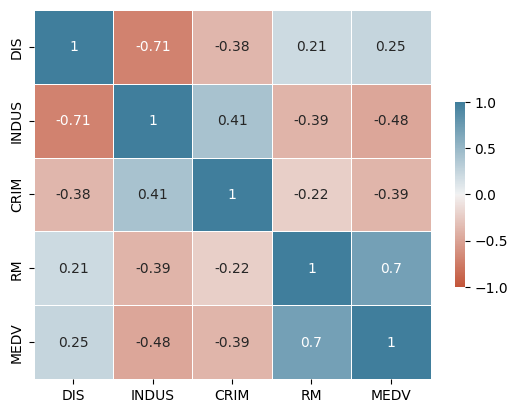

In [6]:
sns.heatmap(
    data=df[cols].corr(),
    cmap=sns.diverging_palette(20, 230, as_cmap=True),
    center=0,
    vmin=-1,
    vmax=1,
    linewidths=0.5,
    cbar_kws={"shrink": 0.5},
    annot=True
)

<Axes: xlabel='RM', ylabel='MEDV'>

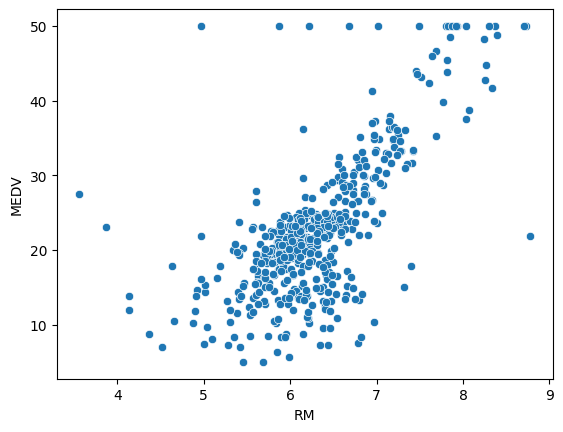

In [7]:
sns.scatterplot(data=df,x=df.RM,y=df.MEDV)

# CREANDO EL MODELO DE REGRESIÓN CON SCIKIT-LEARN

X = RM : promedio de habitaciones de un departamento
Y = MEDV : valor promedio del departamento

## ESTANDARIZAMOS LOS DATOS PARA EL MODELO

In [9]:
X = df['RM'].values.reshape(-1, 1)
y = df['MEDV'].values.reshape(-1, 1)


In [10]:
sc_x = StandardScaler()
sc_y = StandardScaler()

X_std = sc_x.fit_transform(X)
y_std = sc_y.fit_transform(y)


## CREO EL MODELO DE REGRESIÓN LINEAL

In [ ]:
slr = LinearRegression()
slr.fit(X_std,y_std)
slr.predict(X_std)

# GRAFICAMOS LOS RESULTADOS

Text(0.5, 0, 'Promedio de habitaciones del deparamento(RM)')

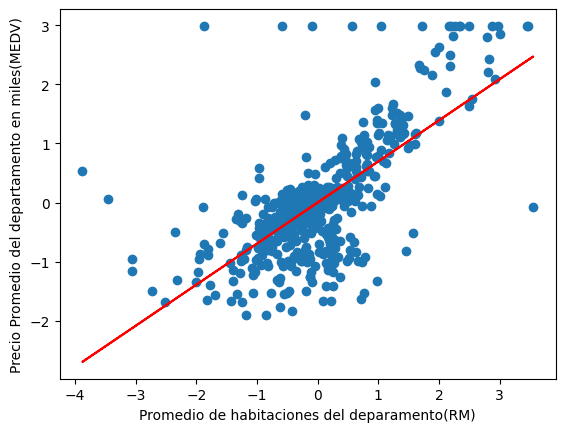

In [12]:
plt.scatter(X_std,y_std)
plt.plot(X_std,slr.predict(X_std),color='red')
plt.ylabel("Precio Promedio del departamento en miles(MEDV)")
plt.xlabel("Promedio de habitaciones del deparamento(RM)")

PROBANDO PREDICCIONES

In [13]:
num_habitaciones = 5
num_habitaciones_std = sc_x.transform(np.array([num_habitaciones]).reshape(-1,1))
print("EL PRECIO DE UN DPTO CON 5 HABITACIONES ES DE :",sc_y.inverse_transform(slr.predict(num_habitaciones_std))*1000)

EL PRECIO DE UN DPTO CON 5 HABITACIONES ES DE : [[10839.92412946]]


# GUARDAMOS NUESTRO MODELO

In [14]:
import joblib
joblib.dump(slr,'housing-ml.pkl')

['housing-ml.pkl']

# GUARDAMOS LOS SCALERS

In [15]:
joblib.dump(sc_x,'scaler_x.pkl')
joblib.dump(sc_y,'scaler_y.pkl')

['scaler_y.pkl']